Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.losses import categorical_crossentropy

import tensorflow_datasets as tfds

from alibi.explainers import GradientSimilarity

from skimage.transform import resize

from alibi.datasets import fetch_imagenet_10

Utils

In [2]:
def plot_similar(ds, expls, int_to_str, mean_channels, figsize=(20, 20)):
    """Plots original instances and similar instances.

    Parameters
    ----------
    ds
        List of dictionaries containing instances to plot, labels and predictions.
    expls
        Similarity explainer explanation object.
    int_to_str
        Dictionary mapping label's number to label's names.
    mean_channels
        Mean channels to add to the images for visualization.
    figsize
        Figure size.

    Returns
    ------
    None
    """
    fig, axes = plt.subplots(5, 6, figsize=figsize, sharex=False)
    for j in range(len(ds)):
        d = ds[j]
        axes[j, 0].imshow(BGR_to_RGB(d['x']))
        label_orig = int_to_str[d['y']].split(',')[0]
        if len(label_orig) > 16:
            label_orig = label_orig[:13] + '...'
        pred_orig = int_to_str[d['pred']].split(',')[0]
        if len(pred_orig) > 16:
            pred_orig = pred_orig[:13] + '...'
        if j == 0:
            title_orig = "Original instance"
            axes[j, 0].set_title(f"{title_orig} \n" +
                                 f"{len(title_orig) * '='} \n" +
                                 f"Label: {label_orig} \n" +
                                 f"Prediction: {pred_orig} ")

        else:
            axes[j, 0].set_title(f"Label: {label_orig} \n" +
                                 f"Prediction: {pred_orig} ")
        axes[j, 0].axis('off')
        for i in range(expls.data['most_similar'].shape[0]):
            label_sim = int_to_str[d['y_sim'][i]].split(',')[0]
            if len(label_sim) > 16:
                label_sim = label_sim[:13] + '...'
            pred_sim = int_to_str[d['preds_sim'][i]].split(',')[0]
            if len(pred_sim) > 16:
                pred_sim = pred_sim[:13] + '...'
            most_similar = BGR_to_RGB((expls.data['most_similar'][j] + mean_channels).astype(int)[i])

            axes[j, i + 1].imshow(most_similar, cmap='gray')
            if j == 0:
                title_most_sim = f"{i+1}{append_int(i+1)} most similar instance"
                axes[j, i + 1].set_title(f"{title_most_sim} \n" +
                                         f"{len(title_most_sim) * '='} \n"+
                                         f"Label: {label_sim} \n" +
                                         f"Prediction: {pred_sim}")
            else:
                axes[j, i + 1].set_title(f"Label: {label_sim} \n" +
                                         f"Prediction: {pred_sim}")
            axes[j, i + 1].axis('off')

    plt.show()


def plot_distributions(ds, expls, int_to_str, figsize=(20, 20)):
    """Plots original instances and scores distributions per class.

    Parameters
    ----------
    ds
        List of dictionaries containing instances to plot, labels and predictions.
    expls
        Similarity explainer explanation object.
    int_to_str
        Dictionary mapping label's number to label's names.
    figsize
        Figure size.

    Returns
    ------
    None
    """

    fig, axes = plt.subplots(5, 2, figsize=figsize, sharex=False)

    for i in range(len(ds)):
        d = ds[i]

        y_sim = d['y_sim']
        preds_sim = d['preds_sim']
        y = d['y']
        pred = d['pred']
        df_ditribution = pd.DataFrame({'y_sim': y_sim,
                                       'scores': expls.data['scores'][i]})

        axes[i, 0].imshow(BGR_to_RGB(d['x']))
        if i == 0:
            title_orig = "Original instance"
            axes[i, 0].set_title(f"{title_orig} \n " +
                                 f"{len(title_orig) * '='} \n" +
                                 f"Label: {d['y']} - {int_to_str[d['y']]}  \n" +
                                 f"Prediction: {d['pred']} - {int_to_str[d['pred']].split(',')[0]} ")
        else:
            axes[i, 0].set_title(f"Label: {d['y']} - {int_to_str[d['y']].split(',')[0]}  \n" +
                                 f"Prediction: {d['pred']} - {int_to_str[d['pred']].split(',')[0]} ")
        axes[i, 0].axis('off')
        df_y = df_ditribution.groupby('y_sim')['scores'].mean()
        df_y.index = [int_to_str[i] for i in df_y.index]
        df_y.sort_values(ascending=True).plot(kind='barh', ax=axes[i, 1])
        if i == 0:
            title_true_class = "Averaged scores for each true class in reference set"
            axes[i, 1].set_title(f"{title_true_class} \n" +
                                 f"{len(title_true_class) * '='} \n ")

    fig.tight_layout()
    plt.show()

def append_int(num):
    """Converts an integer into an ordinal (ex. 1 -> 1st, 2 -> 2nd, etc.).

    Parameters
    ----------
    num
        Integer number.

    Returns
    -------
    Ordinal suffixes.
    """
    if num > 9:
        secondToLastDigit = str(num)[-2]
        if secondToLastDigit == '1':
            return 'th'
    lastDigit = num % 10
    if (lastDigit == 1):
        return 'st'
    elif (lastDigit == 2):
        return 'nd'
    elif (lastDigit == 3):
        return 'rd'
    else:
        return 'th'

def substract_mean_channel(X):
    """Substracts the mean channels from a batch of images.

    Parameters
    ----------
    X
        Batches of images to substract the mean channel from.
    Returns
    -------
    Batch of images.
    """
    assert len(X.shape) == 4
    mean_channels = np.array([103.939, 116.779, 123.68]).reshape(1, 1, 1, -1)
    X_mean = X - mean_channels
    return X_mean, mean_channels

def BGR_to_RGB(X):
    if len(X.shape) == 4:
        return X[:, :,:,::-1]
    elif len(X.shape) == 3:
        return X[:,:,::-1]
    else:
        raise ValueError('Incorrect shape')

Load data

In [8]:
dataset_train = tfds.load('imagenet2012_subset', split='train', as_supervised=True)
dataset_train_numpy = tfds.as_numpy(dataset_train)

# Train DATA
Verarbeite ImageNet zu einem Subset %1 12,811 (https://www.tensorflow.org/datasets/catalog/imagenet2012_subset)

Vorraussetzung: Manueles runterladen des Originaldatensatzes ~ 138 GB 

--------------------    STEP 1  ----------------------------

Time: 195min

Time (nach Optimierung): 17min

In [9]:
first_image = True
training_set = 0    # Training_Images
final_training_set = 0
count_iter = 0
final_ts_first = True

label_set = np.array([], dtype='int64')

count = 0

for image, label in dataset_train_numpy:
    #print(image, label)             #image -> (len, high, clr)  TODO: RESIZE
    # Resize image to (224,224,3) & int (0,255) format
    new_img = resize(image, (224,224), preserve_range=np.uint8).astype(int)
    # new TODO: switch GBR to RGB
    new_img = new_img[:,:,::-1]
    # TODO: ADD Dimiension to archiv (#image_counter, 224,224,3)
    new_img = new_img[np.newaxis]
    # TODO: ADD final image to ndarray
    if first_image:
        training_set = new_img
        first_image = False
    else:
        #training_set = np.append(training_set, image_countable, axis=0)
        training_set = np.concatenate((training_set, new_img), axis=0)
        if count_iter == 1000:
            
            if final_ts_first:
                final_training_set = training_set
                final_ts_first = False
            else:
                final_training_set = np.concatenate((final_training_set, training_set), axis=0)

            training_set = 0
            count_iter = 0
            first_image = True

    # TODO: Create Label List
    label_set = np.append(label_set, label)

    count_iter += 1

    # TEST
    #print("Count: ", count, ", Count_iter: ", count_iter)
    count = count + 1

if count_iter != 0:
    final_training_set = np.concatenate((final_training_set, training_set), axis=0)

#X_train
X_train = final_training_set
#y_train 
y_train = label_set

In [ ]:
# TEST Validation have to be 12811 img
print(X_train.shape)
print(y_train.shape)

(12811, 224, 224, 3)
(12811,)


%1 ---

In [ ]:
# Speicher X_train & y_train
np.save('data\X_train.npy', X_train)  
np.save('data\y_train.npy', y_train)

--------------------    STEP 2  ----------------------------

Time: 11s

In [ ]:
X_train = np.load('data\X_train.npy')

In [ ]:
X_train, mean_channels = substract_mean_channel(X_train)

In [ ]:
# Speicher X_train & mean_channels
np.save('data\X_train_smc.npy', X_train)
np.save('data\mean_channels.npy', mean_channels)

# Test DATA
50000

In diesem Umfand ist der Test DataSet nicht notwendig. Es reichen aus 5 Bilder zu verarbeiten die getestet werden sollen. (SKIP STEP 3)

--------------------    STEP 3  ----------------------------

LOAD DATA

In [ ]:
dataset_test = tfds.load('imagenet2012_subset', split='validation', as_supervised=True)
dataset_test_numpy = tfds.as_numpy(dataset_test)

114m

In [ ]:
first_image = True
training_set = 0    # Training_Images
final_training_set = 0
count_iter = 0
final_ts_first = True

label_set = np.array([], dtype='int64')

count = 0

for image, label in dataset_test_numpy:
    #print(image, label)             #image -> (len, high, clr)  TODO: RESIZE
    # Resize image to (224,224,3) & int (0,255) format
    new_img = resize(image, (224,224), preserve_range=np.uint8).astype(int)
    # new TODO: switch GBR to RGB
    new_img = new_img[:,:,::-1]
    # TODO: ADD Dimiension to archiv (#image_counter, 224,224,3)
    new_img = new_img[np.newaxis]
    # TODO: ADD final image to ndarray
    if first_image:
        training_set = new_img
        first_image = False
    else:
        #training_set = np.append(training_set, image_countable, axis=0)
        training_set = np.concatenate((training_set, new_img), axis=0)
        if count_iter == 1000:

            if final_ts_first:
                final_training_set = training_set
                final_ts_first = False
            else:
                final_training_set = np.concatenate((final_training_set, training_set), axis=0)

            training_set = 0
            count_iter = 0
            first_image = True

    # TODO: Create Label List
    label_set = np.append(label_set, label)

    count_iter += 1

    # TEST
    #print("Count: ", count, ", Count_iter: ", count_iter)
    count = count + 1

if count_iter != 0:
    final_training_set = np.concatenate((final_training_set, training_set), axis=0)

#X_train
X_test = final_training_set
#y_train 
y_test = label_set

In [ ]:
np.save('data\X_test.npy', X_test)
np.save('data\y_test.npy', y_test)

--------------------    STEP 4  ----------------------------

In [3]:
# Lade eigenes Dataset mit den 10 Bildern welches in image_transformer.ipynb erstellt wurden
X_test = np.load('data/X_test30.npy')
y_test = np.load('data/y_test30.npy')

In [4]:
X_test, _ = substract_mean_channel(X_test)

In [ ]:
np.save('data\X_test_smc.npy', X_test)

--------------------    STEP 5  ----------------------------

In [ ]:
imagenet10 = fetch_imagenet_10()
int_to_str = imagenet10['int_to_str_labels']
np.save('data\int_to_str.npy', int_to_str)

--------------------    STEP 6  ----------------------------

In [5]:
# LOAD y
# y_train = np.load('data\y_train.npy')
# y_test = np.load('data\y_test10.npy')

In [5]:
# y_train = to_categorical(y_train, num_classes=1000)
#   y_train (numpy.ndarray)
y_test = to_categorical(y_test, num_classes=1000)
#   y_test (numpy.ndarray)

In [ ]:
np.save('data\y_train_to_cate.npy', y_train)
np.save('data\y_test_to_cate.npy', y_test)

--------------------    DONE  ----------------------------

Load model

In [6]:
model = ResNet50(weights='imagenet')
preds = model(X_test).numpy().argmax(axis=1)
acc = accuracy_score(y_test.argmax(axis=1), preds)

In [7]:
print('Test accuracy: ', acc)

Test accuracy:  0.5


Find similar instances

    Initializing a GradientSimilarity explainer instance.

Lade alle im Vorfeld vorbereiteten Daten

In [8]:
#   LOAD MODEL
model = ResNet50(weights='imagenet')
#   LOAD DATASETs
X_train = np.load('data\X_train_smc.npy')    
y_train = np.load('data\y_train_to_cate.npy')

#X_test = np.load('data\X_test_smc.npy')      
#y_test = np.load('data\y_test_to_cate.npy')

imagenet10 = fetch_imagenet_10()
int_to_str = imagenet10['int_to_str_labels']

mean_channels = np.load('data\mean_channels.npy')

In [9]:
gsm = GradientSimilarity(model, categorical_crossentropy, precompute_grads=False, sim_fn='grad_cos')

c:\Users\lenz6\AppData\Local\Programs\Python\Python39\lib\site-packages\alibi\explainers\similarity\grad.py:139: UserWarning: Found 106 non-trainable parameters in the model. These parameters don't have gradients and will not be included in the computation of gradient similarity. This might be because your model has layers that track statistics using non-trainable parameters such as batch normalization layers. In this case, you don't need to worry. Otherwise it's because you have set some parameters to be non-trainable and alibi is letting you know.
  warnings.warn(warning_msg)


    Fitting the explainer on the training data.

In [10]:
gsm.fit(X_train, y_train)

GradientSimilarity(meta={
  'name': 'GradientSimilarity',
  'type': ['whitebox'],
  'explanations': ['local'],
  'params': {
              'sim_fn_name': 'grad_cos',
              'store_grads': False,
              'backend_name': 'tensorflow',
              'task_name': 'classification'}
            ,
  'version': '0.9.5'}
)

    Selecting 5 random classes out of 10 and 1 random instance per class from the test set (5 test instances in total).

In [11]:
# Wähle die ersten 5 Bilder aus deinem Test Set
idxs_samples = np.array([25, 26, 27, 28, 29])

#idxs_samples = np.random.choice(idxs_samples, 5, replace=False)
#prnt(idxs_samples)

X_sample, y_sample = X_test[idxs_samples], y_test[idxs_samples]
preds = model(X_sample).numpy().argmax(axis=1)

In [12]:
print(preds)

[299 776 718 582 509]


    Getting the most similar instance for the each of the 5 test samples.
Time: 12min     mit dem Beispiel aus Similarity explanations for ImageNet

Time: 143m      für unseren Anwendungsfall mit 12.811 Bilder im Trainingsdatensatz und 5 zu testenden Bildern

In [13]:
expls = gsm.explain(X_sample, y_sample)

In [15]:
mean_channels = np.load('data\mean_channels.npy')
imagenet10 = fetch_imagenet_10()
int_to_str = imagenet10['int_to_str_labels']    #still load fetch_imagenet_10()


Visualizations

In [14]:
ds = []
for j in range(len(X_sample)):
    y_sim = y_train[expls.data['ordered_indices'][j]].argmax(axis=1)
    X_sim = X_train[expls.data['ordered_indices'][j][:5]]
    preds_sim = model(X_sim).numpy().argmax(axis=1)

    d = {'x': (X_sample + mean_channels).astype(int)[j],
         'y': y_sample[j].argmax(),
         'pred':preds[j],
         'y_sim': y_sim,
         'preds_sim': preds_sim}
    ds.append(d)

Most similar instances

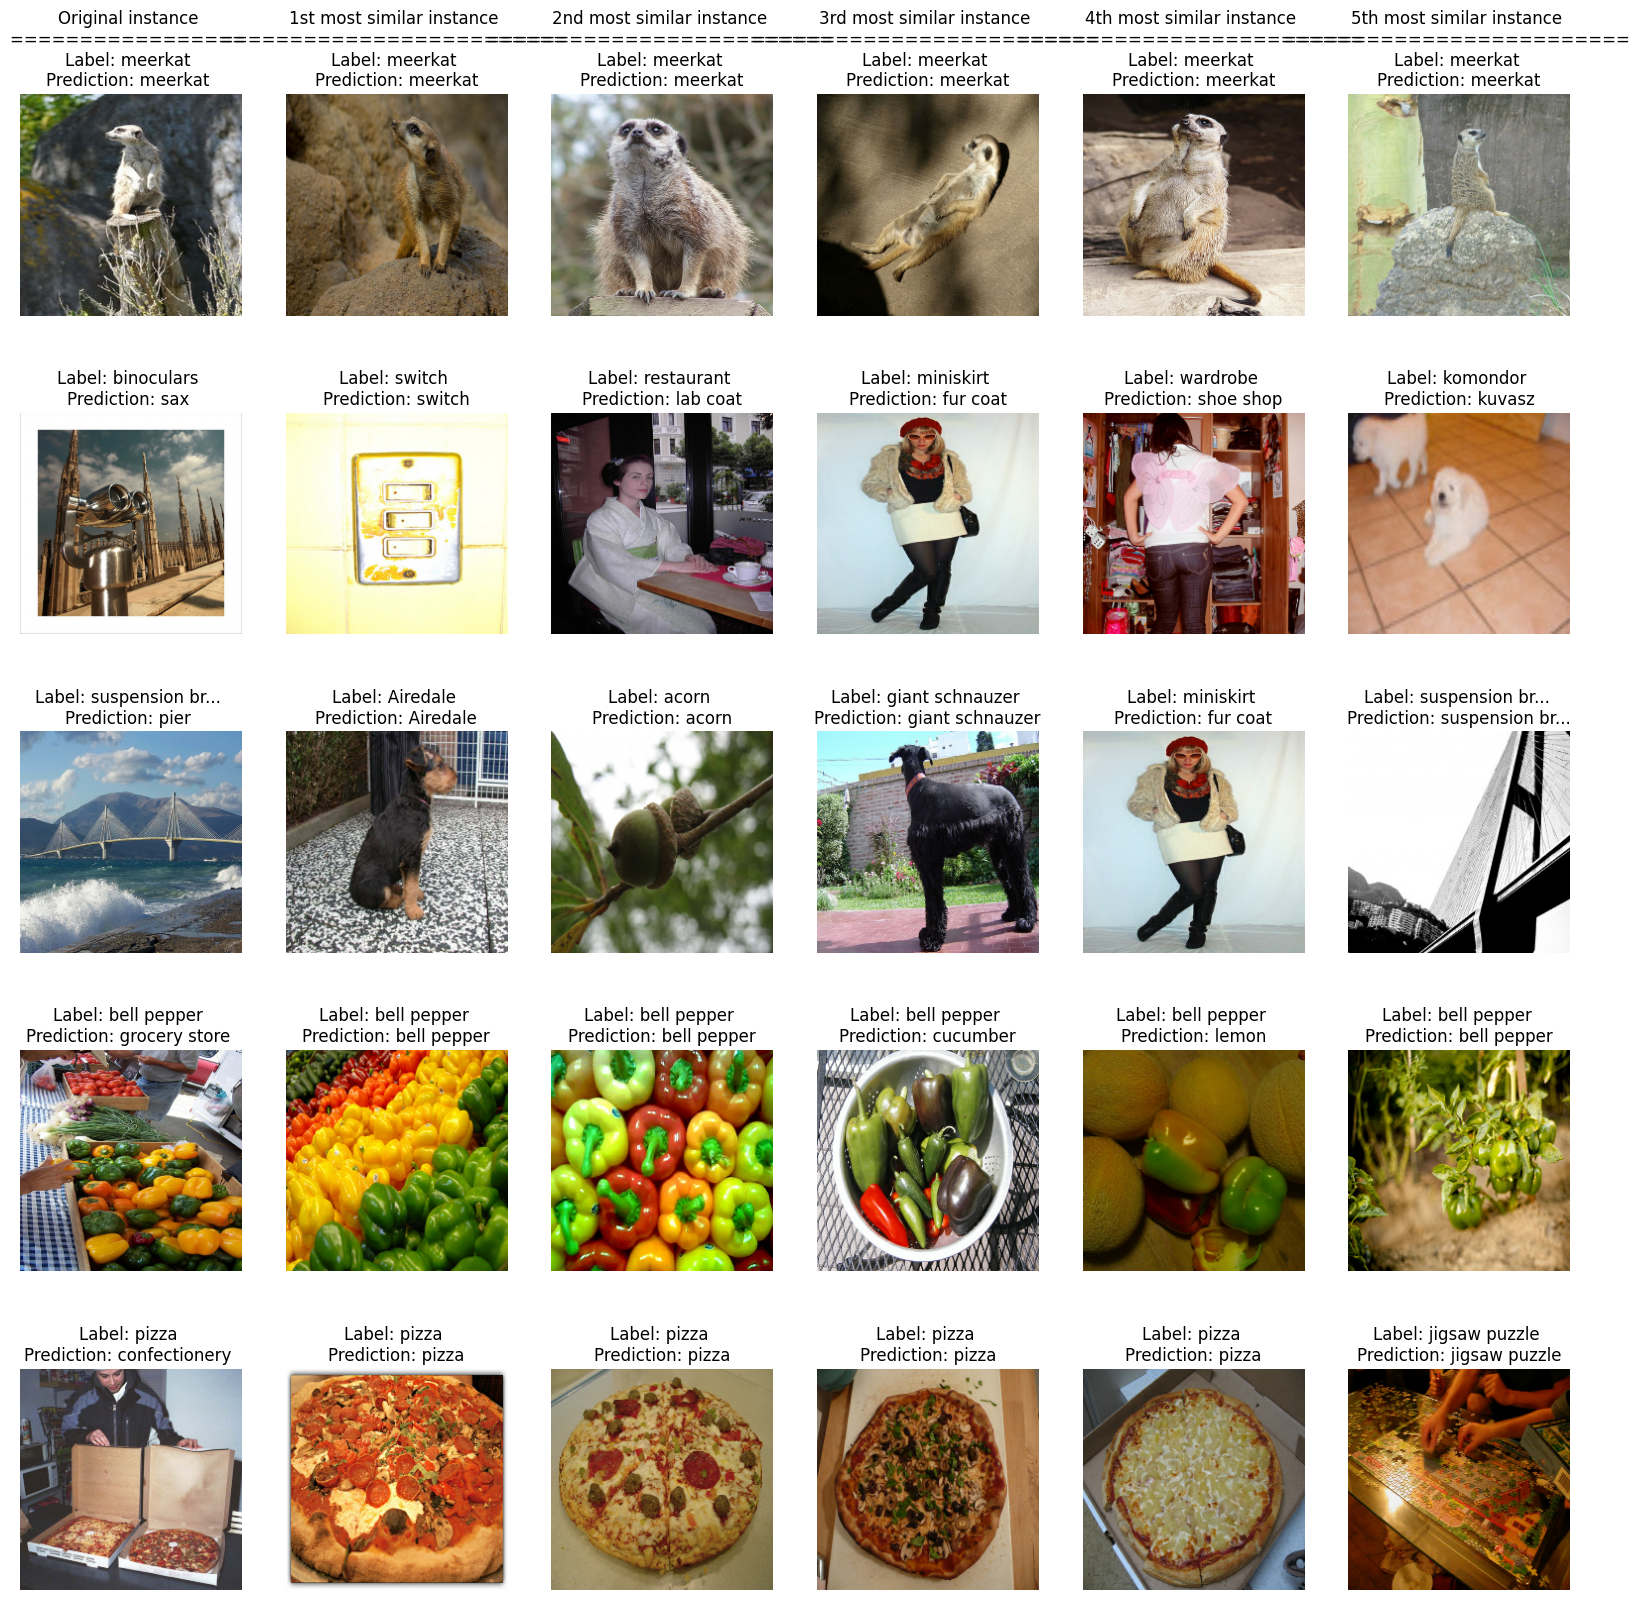

In [15]:
plot_similar(ds, expls, int_to_str, mean_channels)

Most similar labels distributions


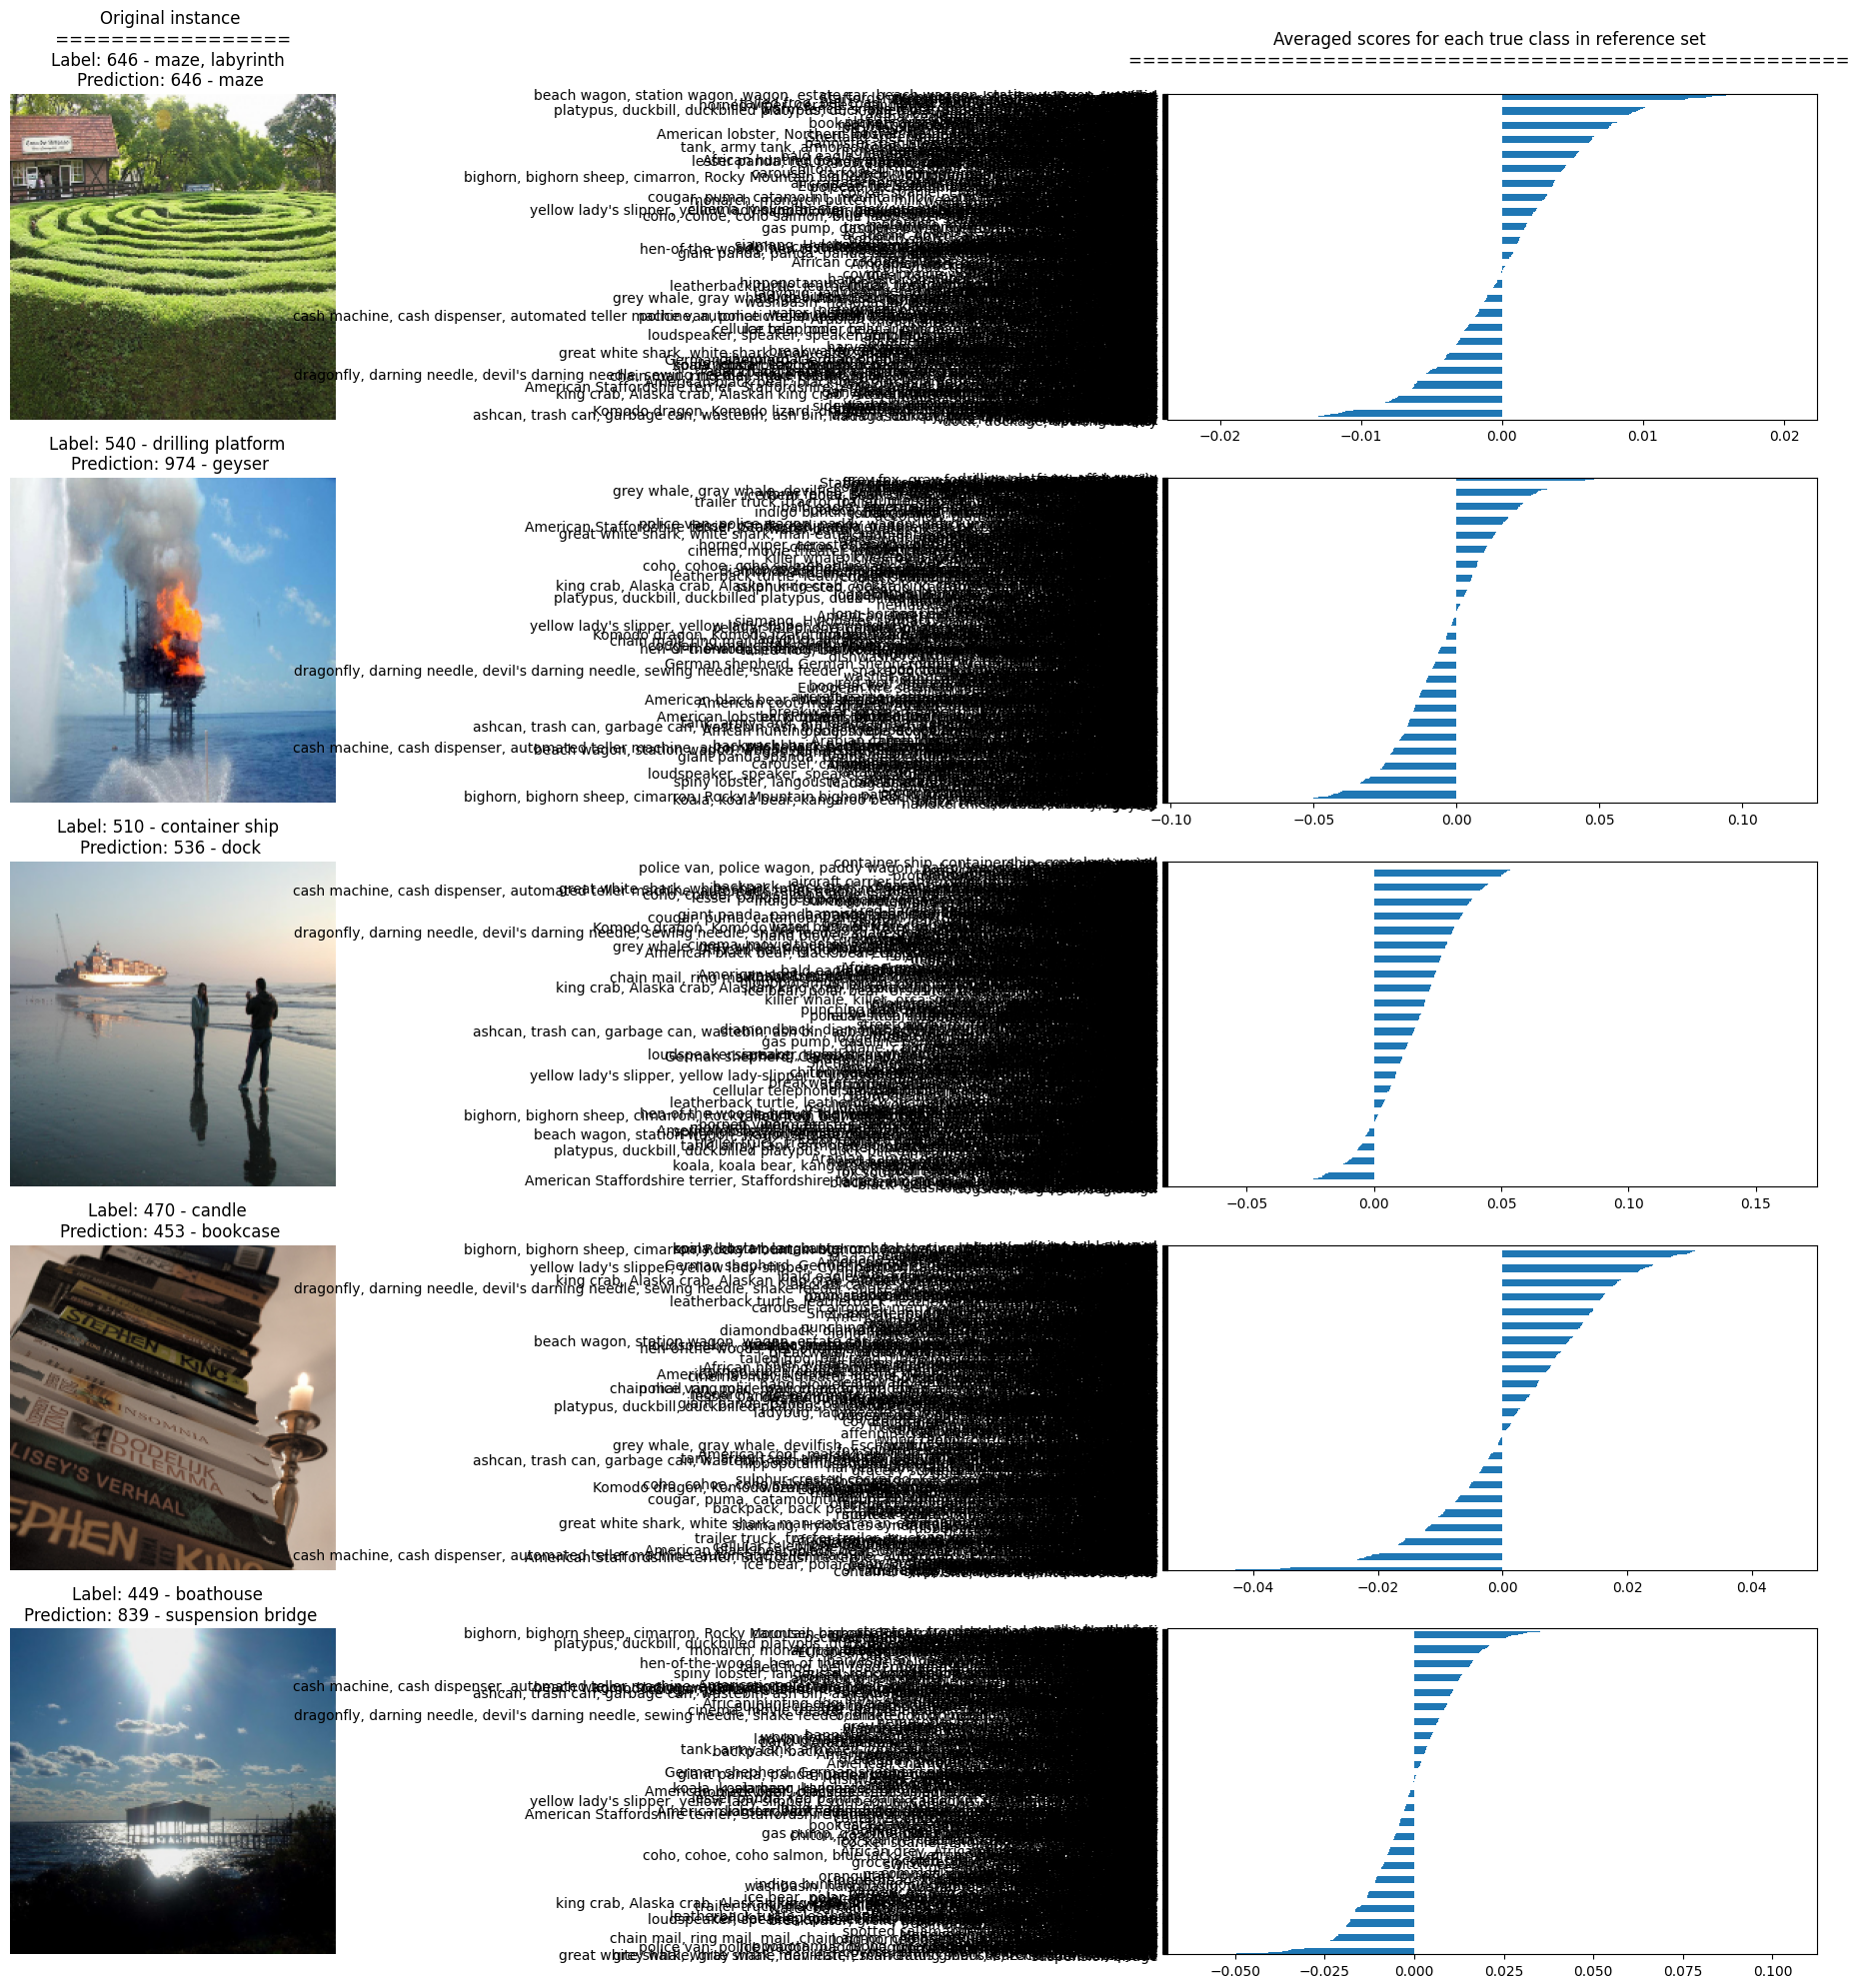

In [ ]:
plot_distributions(ds, expls, int_to_str)